# Store Sales Time Series Analysis Using Singular Spectrum Analysis (SSA)

# Introduction

Singular Spectrum Analysis (SSA) is a statistical method for time series exploration and forecasting. This nonparametric method can be applied to stationary and nonstationary time series and enables the identification and separation of the main components of the series: trend, oscillatory components, and noise. 

In this project, Singular Spectrum Analysis is applied to explore the sales time series from the Store Sales – Time Series Forecasting dataset available on [Kaggle]( www.kaggle.com/competitions/store-sales-time-series-forecasting/overview/description). The analysis focuses on the sales variable for store_nbr = 1 and the BEVERAGES product family, using the train dataset. The objective is to identify the main underlying components of the series.


## Import  libraries 

In [35]:
# ============================
# Import standard libraries
# ============================
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import plotly
import plotly.graph_objects as go
import plotly.express as px

import torch

from scipy.signal import welch, find_peaks
from scipy.signal import hilbert



# ============================
# Project directories
# ============================
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" 
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR))

# ============================
# Project modules
# ============================
import ssa
import plotssa


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used is {device}")

Device used is cpu


In [36]:

import importlib
importlib.reload(ssa)

import plotssa
importlib.reload(plotssa)

<module 'plotssa' from 'C:\\Users\\normaqp\\Documents\\Pytorch_Projects\\SSA_pytorch\\stores-sales-ssa\\src\\plotssa.py'>


## Load dataset


In [37]:
# Load data 
sales_ts = pd.read_csv(DATA_DIR / "sales.csv")

# convert data time to pandas datatime
sales_ts["date"] = pd.to_datetime(sales_ts["date"])

# convert usual index to date index
sales_ts = sales_ts.set_index("date")

# convert the column sales to a pandas Series 
sales_ts = sales_ts["sales"]



##  Basic Exploratory Data Analysis


In [38]:
# Dataset overview
sales_ts.head()

date
2013-01-01       0.0
2013-01-02    1091.0
2013-01-03     919.0
2013-01-04     953.0
2013-01-05    1160.0
Name: sales, dtype: float64

In [39]:
# Dataset information
sales_ts.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 1684 entries, 2013-01-01 to 2017-08-15
Series name: sales
Non-Null Count  Dtype  
--------------  -----  
1684 non-null   float64
dtypes: float64(1)
memory usage: 26.3 KB


In [40]:
# Dataset statistics
sales_ts.describe()

count    1684.000000
mean     1587.748812
std       726.870056
min         0.000000
25%       970.750000
50%      1674.000000
75%      2206.000000
max      5051.000000
Name: sales, dtype: float64

In [41]:
# timeseries plot
sales_data = go.Scatter(x=sales_ts.index, y=sales_ts, mode='lines', name='Sales')
layout = go.Layout(title='Daily Sales from 2013 to 2017', xaxis=dict(title='Date'),
                   yaxis=dict(title='Beverage(units)'))
fig = go.Figure(data=[sales_data], layout = layout)
fig.show()

The figure below shows the daily sales time series for the selected store over the study period.  

**Observation.** 
The daily sales series exhibits strong variability with frequent short-term fluctuations and several pronounced spikes. Although a long-term increase is visually apparent, the trend and oscillatory components are difficult to distinguish directly from the raw observations. This motivates the use of Singular Spectrum Analysis (SSA) to separate the underlying trend from oscillatory and residual components.

## Sequential SSA Workflow

The analysis consists of two stages.

In the first stage, a small window length is used  to estimate the long-term trend of the original time series. In the second stage, a larger window length is applied to the residual from Stage 1, increasing the spectral resolution of SSA and allowing individual oscillatory modes to be separated into well-defined component pairs.

### Stage 1 (Small window length)

- Embedding (Hankel matrix)
- Singular Value Decomposition (SVD)
- Visual inspection of the elementary components
- Trend extraction

### Stage 2 (Large window length)

- Embedding of the residual from Stage 1
- Singular Value Decomposition (SVD)
- Visual inspection of the elementary components
- Grouping
- Reconstruction of oscillatory components

### Stage 1: Trend Extraction with a Small Window Length

A window length of L = 14 was selected, corresponding to twice the dominant weekly period (7 days) identified in the sales series. The objective of this first stage is to obtain an estimate of the long-term trend before analyzing the residual with a larger window length.

In [42]:
sales_np = sales_ts.to_numpy()

In [43]:
# ============================
# Embedding and SVDecomposition
# ============================
results1 = ssa.svd(sales_np, L=14)

Running SSA with L=14


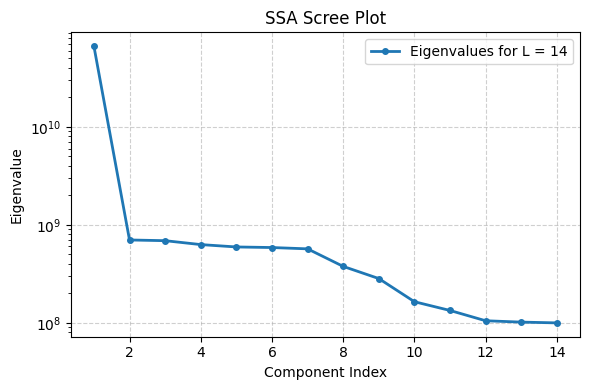

In [44]:
# ============================
# Visual inspection
# ============================

# Eigenvalues 
S1 = results1["S"]
eigenvals1 = ssa.eigenvalues(S1)

# plot_scree(S)
plotssa.plot_scree(eigenvals1, label="Eigenvalues for L = 14")




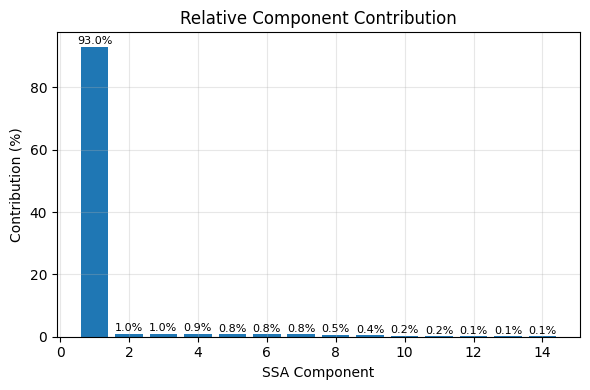

In [45]:
# plot relative contribution
plotssa.relative_contribution(eigenvals1)

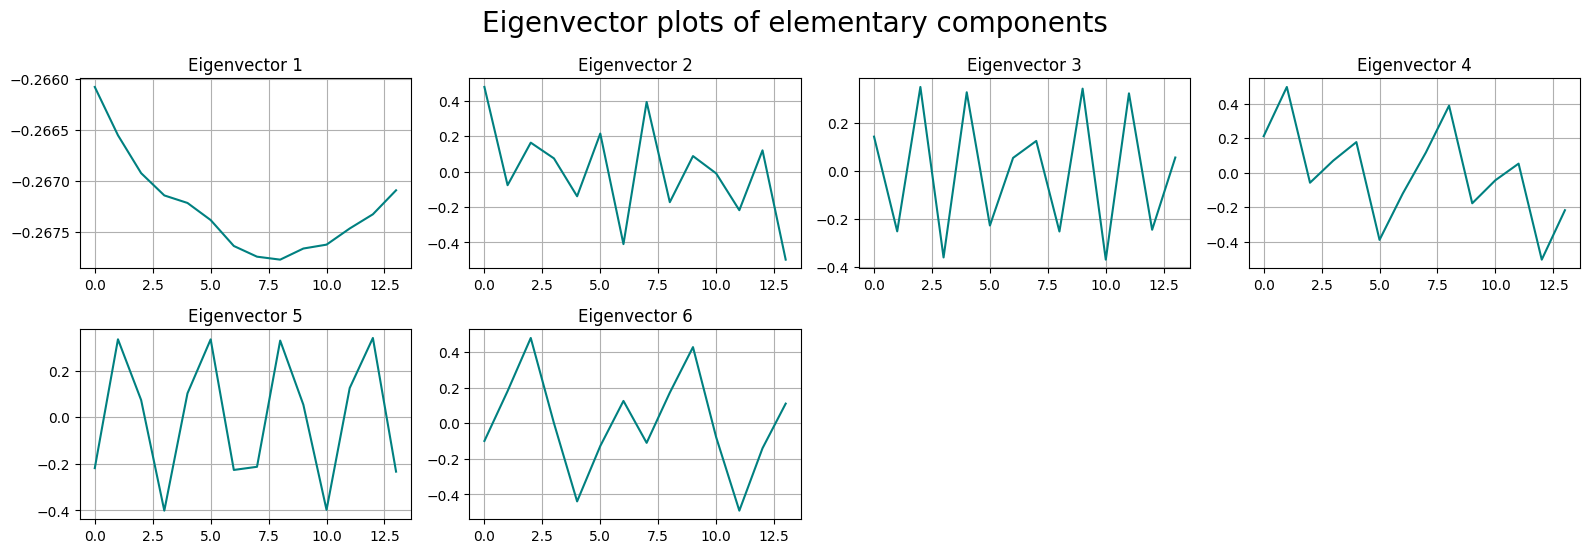

In [46]:
#  Eigenvectors 
U1 = results1["U"][:]
plotssa.plot_eigenvecs(U1, n=6)

The scree plot indicates that the first component captures the largest contribution, while the corresponding eigenvector  exhibits the smooth behavior characteristic of the long-term trend. Therefore, the first component is identified as the trend.

In [47]:
# ============================
# Trend extraction
# ============================

# Construct the elementary groups (each eigenvector represents a group)
elementary_grouping = list(range(len(eigenvals1)))

# Extract the trend
trend = ssa.reconstruct_group(results1, [0])

# The elementary reconstructed series is  the reconstructed series obtained by the elementary grouping
elem_rec_ts= ssa.reconstruct_group(results1, elementary_grouping)

# Residual 
residual = elem_rec_ts - trend




In [48]:
# Plot the original timeseries and trend
trend_np = trend.numpy()

fig = go.Figure()

# Original Series
fig.add_trace(
    go.Scatter(
        x= sales_ts.index,
        y=sales_ts,
        mode="lines",
        name="Daily Sales"
    )
)

# SSA trend
fig.add_trace(
    go.Scatter(
        x= sales_ts.index,
        y=trend_np,
        mode="lines",
        name="SSA Trend",
        line=dict(color="red", width=3)
    )
)

fig.update_layout(
    title="Daily Beverage Sales with SSA Trend",
    xaxis_title="Date",
    yaxis_title="Sales (units)"
)

fig.show()

**Observation:** The trend was extracted during the first stage of the sequential SSA decomposition, before analyzing the oscillatory components of the residual series.

This trend shows that:
* Sales remain relatively stable during the first year.
* A gradual upward trend begins in 2014.
* The growth becomes more pronounced from mid-2015 onward.
  


In [49]:
# Residual plot
res_data = go.Scatter(x=sales_ts.index, y=residual, mode='lines', name='Sales')
layout = go.Layout(title='Residual time series', xaxis=dict(title='Date'),
                   yaxis=dict(title='Beverage(units)'))
fig = go.Figure(data=[res_data], layout = layout)
fig.show()

This series is amplitude modulated. We will see that it has a consequence on the way how periodicities are distributed. 

### Stage 2: Reconstruction of oscillatory components


Several embedding window lengths $L$, ranging from 280 to 840 samples (all multiples of 14), were evaluated. Several  values, for instance $L = 360$ and  $840$, provided similar results  that yielded  a good separability of the elementary reconstructed components in the W-correlation matrix.  For the exposition,  $L=840$ was selected. 

In [50]:
# =========================================
# Residual Embedding and SVDecomposition  
# =========================================
results2 = ssa.svd(residual, L=840)

Running SSA with L=840


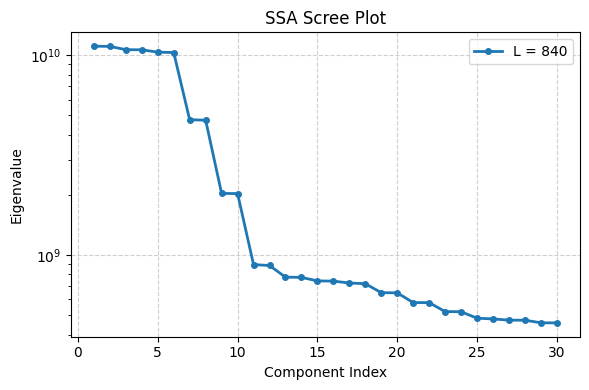

In [51]:
# ============================
# Visual inspection
# ============================

# Eigenvalues 
S2 = results2["S"]
eigenvals2 = ssa.eigenvalues(S2)

# plot_scree(S)
plotssa.plot_scree(eigenvals2, idx=slice(0, 30), label = "L = 840")
plt.show()




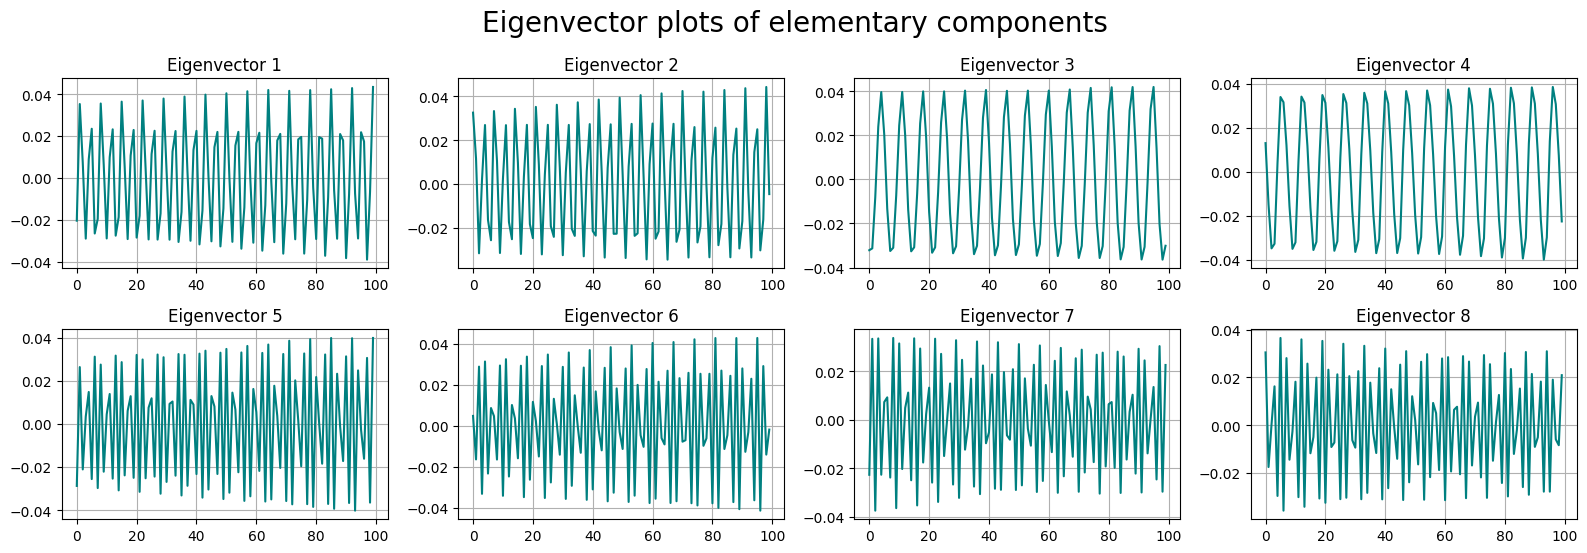

In [52]:
# Eigenvectors: one-dimensional plots
U2 = results2["U"]
plotssa.plot_eigenvecs(U2[:100])

In [53]:
U2.shape

torch.Size([840, 840])

In [54]:
# Weighted-correlation matrix (W-correlation)
ts_rec = []
for i in range(50):
  component_series = ssa.reconstruct_group(results2, group=[i])
  ts_rec.append(component_series)

W = ssa.w_correlation_matrix(ts_rec, L=840)
plotssa.plot_w_correlation(W, "Weighted correlation matrix")


**Observations:**

* Components 1–12:
   * Scree plot: it exhibits a fast decline, with eigenvalues decreasing from approximately $10^{10}$ to $10^9$. This suggests that most of the variance (of the residual) is concentrated in the first components. There are pairs of elementary components sharing similar eigenvalues. 
   * W-matrix: it shows six diagonal blocks of two highly correlated components exhibiting very low W-correlation with the remaining components.
   * Eigenvectors: the plots of elementary eigenvectors indicate that there are paired eigenvectors associated with harmonics oscillating with almost the same frequency.

------ 

* Components 13, 14, 15, 16:
   * W-matrix:  the components show substantial cross-correlations, indicating that they are not isolated oscillatory modes. They can not be grouped in     isolated pairs.  
------  
* Components 17,18,19-20:
   * W-matrix: it shows a clear yellow block  exhibiting high  W-correlation between components 17-18 and 19-20 separately.

------     
* Components 21 onward:
   
   * The scree plot shows a smooth decay without pronounced elbows or abrupt changes. These components have substantially smaller eigenvalues. They can be considered as noise, as suggested by the W-correlation results.
 


The paired eigenvectors associated to harmonic oscillations are:  1-2, 3-4, 5-6, 7-8, 9-10,  11-12, 17-18, 19-20 as can be observed in the pair plots. 

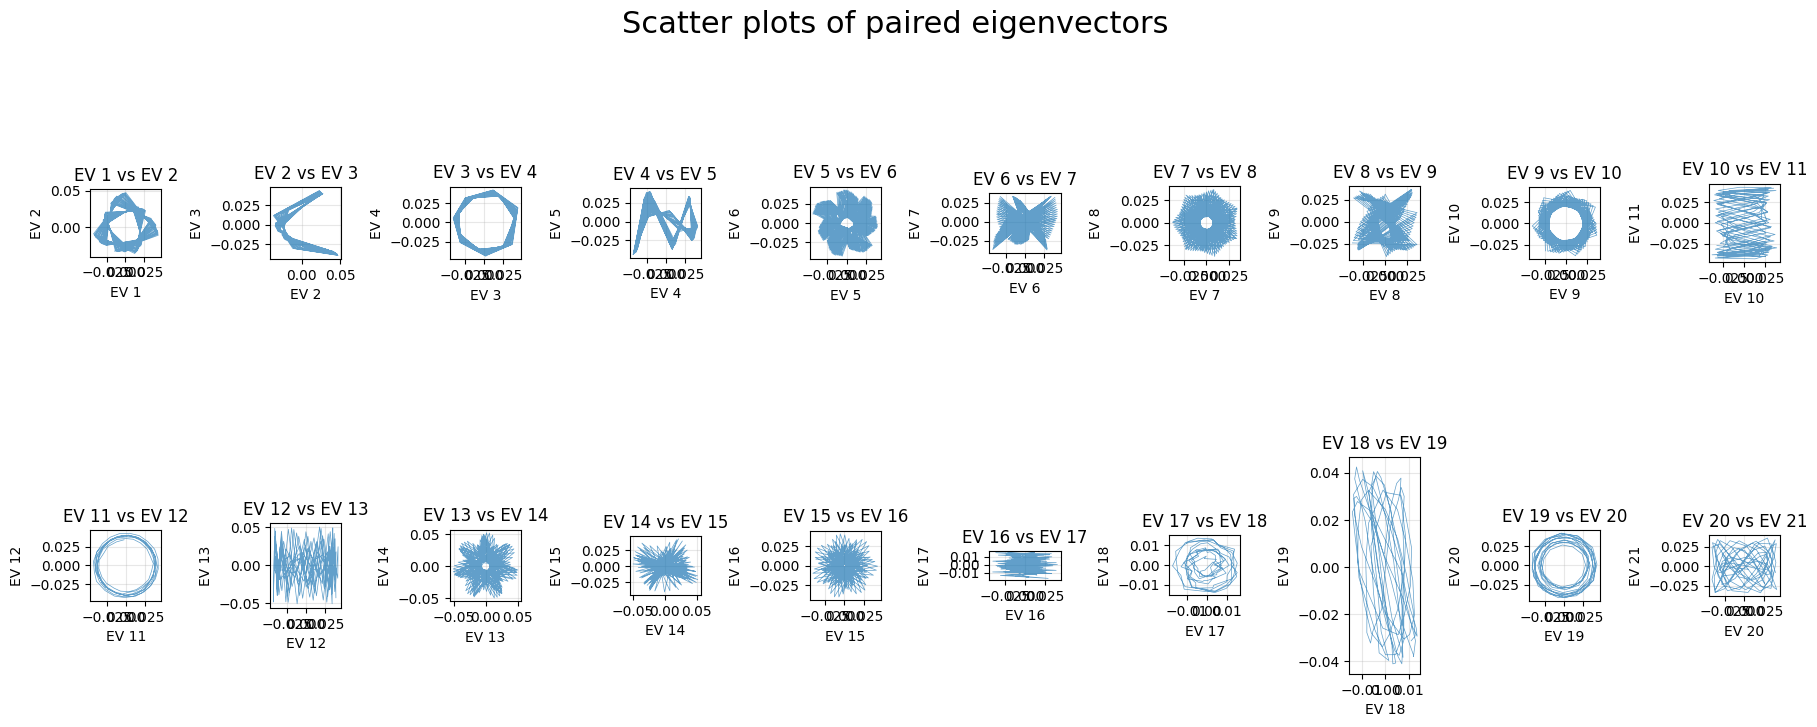

In [55]:
# Eigenvectors: two-dimensional plots
pairs = [(i, i+1) for i in range(20)]
plotssa.plot_eigenvector_pairs(
    U2,
    pairs=pairs,
    n_samples=150,
    figsize=(18, 8)
)

In [56]:
# Checking the periodicity of pairs 9-10 with geometric rotation
u = U2[:,8].cpu().numpy()      # component 9
v = U2[:,9].cpu().numpy()      # component 10

theta = np.unwrap(np.arctan2(v, u))

dtheta = np.diff(theta)

period = 2*np.pi / np.mean(dtheta)

print(period)

3.5242857069492737


In [57]:
# Checking the frequencies and periodicities of the first 30 components
print(25*" = ")
print("Frequencies of elementary components for the  detrended residual")
print(25*" = ")
print(" ")

eigenvals2_sum = np.sum(eigenvals2.cpu().numpy())

rows = []


for i in range(20):
    vec = U2[:, i].cpu().numpy()
    
    current_egvals = eigenvals2[i] # Get the eigenvalue for the current component
    rel_cont_res = (current_egvals / eigenvals2_sum) * 100 # Calculate contribution for the current component
    cum_cont_res = (np.cumsum(current_egvals) / eigenvals2_sum) * 100

    freqs = np.fft.rfftfreq(len(vec), d=1)
    dom = freqs[np.argmax(np.abs(np.fft.rfft(vec)))]
    period = 1 / dom if dom > 0 else np.nan

    rows.append({
        "Component": i+1,
        "Freq (cycles/day)": round(dom, 4),
        "Period (days)": round(period, 3) if not np.isnan(period) else np.nan,
        "Relative contribution (%)": round(float(rel_cont_res), 3),
        "Cumulative contribution (%)": round(float(rel_cont_res), 3),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))


 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
Frequencies of elementary components for the  detrended residual
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
 
 Component  Freq (cycles/day)  Period (days)  Relative contribution (%)  Cumulative contribution (%)
         1             0.2869          3.485                      7.443                        7.443
         2             0.2869          3.485                      7.424                        7.424
         3             0.1429          7.000                      7.151                        7.151
         4             0.1429          7.000                      7.137                        7.137
         5             0.4298          2.327                      6.949                        6.949
         6             0.4298          2.327                      6.916                        6.916
         7             0.4274          2.340                      3.189   

**Observations:**

In the table above, several frequencies recur. The frequencies corresponding to periods of approximately 7, 3.5, and 2.3 days  occur in multiple pairs. The fact that the frequencies of  harmonics are spread out is due to the amplitude modulation of the residual series. 

* Some groups exhibit similar periods but negligible W-correlation. This suggests that similar periodicities may be represented by different SSA component pairs. As shown in the reconstructed components below, groups with the same dominant period can exhibit markedly different temporal evolutions. Whether these components represent distinct oscillatory processes or different manifestations of the same oscillatory structure cannot be determined from SSA alone. Therefore, they were retained as separate groups rather than being merged into a single oscillatory component.


In addition, oscillatory pairs with  periods of approximately 20.5 days (components 11–12), 15.3 days (components 17–18), and 11.7 days (components 19–20) are also identified. 

In the present analysis, only the well-defined oscillatory pairs are retained for reconstruction. The groups are as follows:

| Group| Components. | Frequency | Period | Relative Contr.(%)|
| :--- | :--- | :--- |:--- |:--- |
|1| 1, 2| 0.28  | 3.5 days |14.87|
|2 | 3, 4 |  0.14 |   7 days  |14.29|
| 3 | 5, 6|  0.42  |  2.3 days |13.87|
|4| 7, 8 | 0.42 |    2.3 days |6.36|
|5| 9, 10 | 0.28  | 3.5 days | 2.73|
|6| 11, 12 |  0.049  | 20.5 days|1.20|
|7| 17, 18 |  0.066  | 15.3 days|0.97|
|8| 19, 20 |  0.086   | 11.7 days|0.97|





* The weekly oscillation represents one of the principal oscillatory structures in the residual series, accounting for approximately 14.3% of its total SSA energy. Although it is not the largest oscillatory contribution, its 7-day period naturally corresponds to the weekly sales cycle. 


In [58]:
selected = [0,1,2,3,4,5,6,7,8,9,10,11, 12,17,18,19,20]

share = eigenvals2[selected].sum() / eigenvals2.sum()

print(f"Selected eigentriples explain {share*100:.1f}% of the total residual energy.")

Selected eigentriples explain 55.6% of the total residual energy.


In [59]:
# =========================================
# Grouping 
# =========================================

# Selecting groups following the W-plot, pairplots, scree plot and the previous table

groups = {
    "group1":  [0, 1],                    # T ≈ 3.5 days
    "group2":  [2, 3],                    # T ≈ 7 days
    "group3":  [4, 5],                    # T ≈ 2.3 days
    "group4":  [6, 7],                    # T ≈ 2.3 days
    "group5":  [8, 9],                    # T ≈ 3.5 days
    "group6":  [10, 11],                    # T ≈ 20.5 days
    "group7":  [16, 17],                    # T ≈ 15.3 days
    "group8":  [18, 19],                    # T ≈ 11.7 days
}
# Remaining components are treated as noise
used_idx = sorted([i for g in groups.values() for i in g])
ncomp = len(results2["S"])

noise_idx = [i for i in range(ncomp) if i not in used_idx]


# Reconstruct selected groups
rec_groups = ssa.reconstruct_all_groups(results2, groups)



# Reconstruct noise
rec_groups["noise"] = ssa.reconstruct_group(results2, noise_idx)


In [60]:


# Eigenvalues


# Relative contribution of each elementary component
egvals2 = eigenvals2.cpu().numpy()
contrib = 100 * egvals2 / egvals2.sum()

# Relative contribution of each group
group_contrib = {
    name: contrib[idx].sum()
    for name, idx in groups.items()
}

# DataFrame
df = pd.DataFrame({
    "Relative contribution (%)": group_contrib
})

# Cumulative contribution
df["Cumulative contribution (%)"] = (
    df["Relative contribution (%)"].cumsum()
)

# Round values
df = df.round(2)

print(df)

        Relative contribution (%)  Cumulative contribution (%)
group1                      14.87                        14.87
group2                      14.29                        29.16
group3                      13.87                        43.02
group4                       6.36                        49.38
group5                       2.73                        52.11
group6                       1.20                        53.31
group7                       0.97                        54.27
group8                       0.87                        55.14


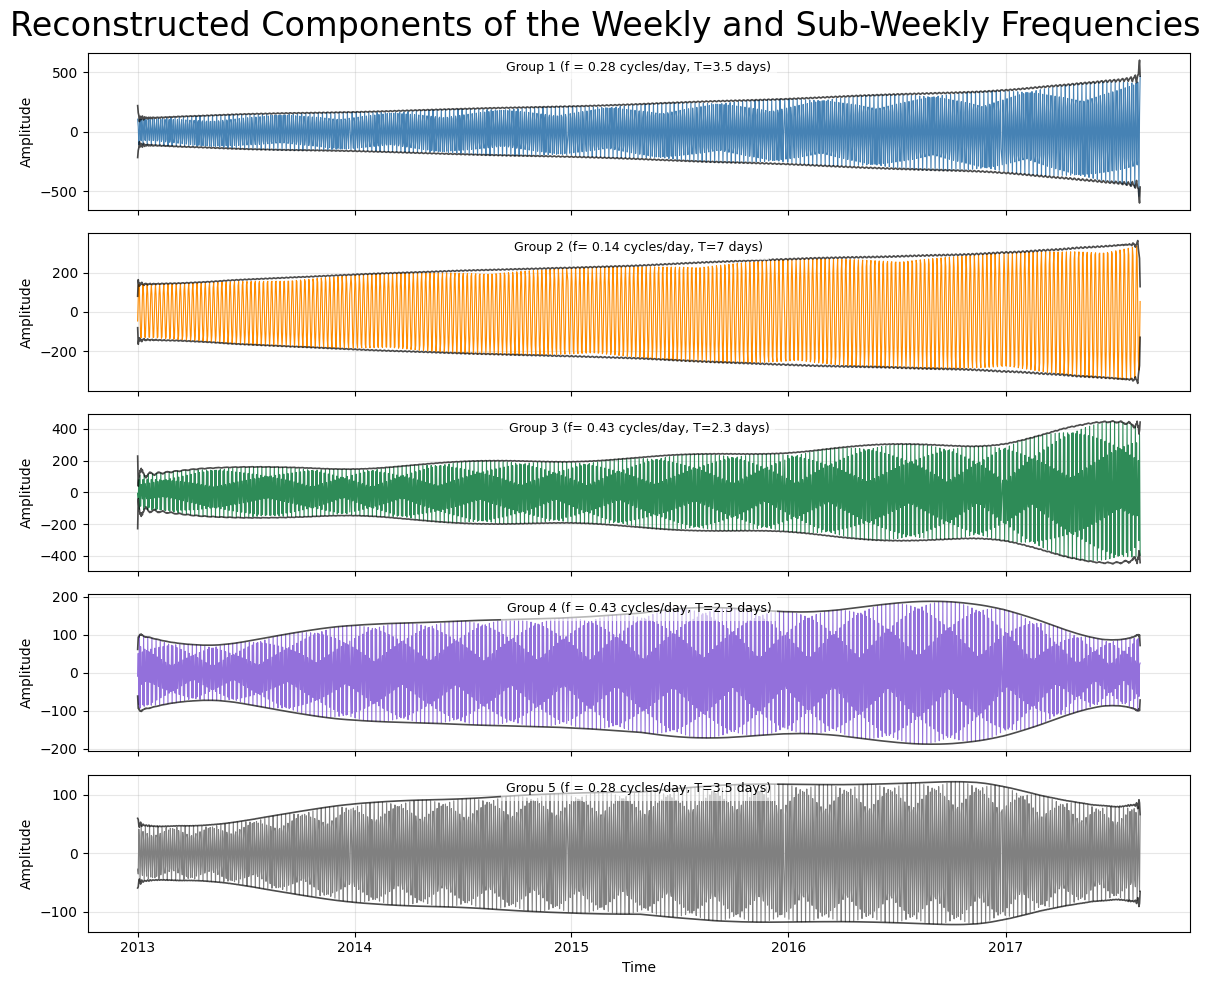

In [61]:
plt.close('all')

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)


# Plots each group
modes1 = {
    "Group 1 (f = 0.28 cycles/day, T=3.5 days)": rec_groups["group1"],
    "Group 2 (f= 0.14 cycles/day, T=7 days)": rec_groups["group2"],
    "Group 3 (f= 0.43 cycles/day, T=2.3 days)": rec_groups["group3"],
    "Group 4 (f = 0.43 cycles/day, T=2.3 days)": rec_groups["group4"],
    "Gropu 5 (f = 0.28 cycles/day, T=3.5 days)": rec_groups["group5"],
}

colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'gray']

x = sales_ts.index
for ax, (title, signal), color in zip(axes, modes1.items(), colors):
    sig_np = signal.cpu().numpy()
    
    ax.plot(x, sig_np, color=color, lw=0.8)
    
    #  # Envelope for oscillations
   
    env = np.abs(hilbert(sig_np))
    ax.plot(x, env,  color='black', lw=1.2, alpha=0.7)
    ax.plot(x, -env, color='black', lw=1.2, alpha=0.7)
    
    ax.text(0.5, 0.95, title,
            transform=ax.transAxes,
            ha='center', va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')

plt.suptitle("Reconstructed Components of the Weekly and Sub-Weekly Frequencies", fontsize = 24 )
plt.tight_layout()
plt.show()
plt.close(fig)

**Observations:** 

In this figure, we can observe that, for instance, the  reconstructed components of Group 3 and Group 4
both  have a period of 2.3 days (a frequency of 0.43 cycles per day). Despite sharing
the same periodicity, their temporal behavior seems different: Group 3
shows a monotonically increasing amplitude over the  years 2013–2017,
while Group 4 exhibits a more modulated amplitude. Their W-correlation for these groups (∣W∣=0.015) further suggests that they represent distinct oscillatory modes rather than the same oscillation. A similar behavior is observed for Groups 1 and 5, which share a comparable period but exhibit different temporal patterns. 

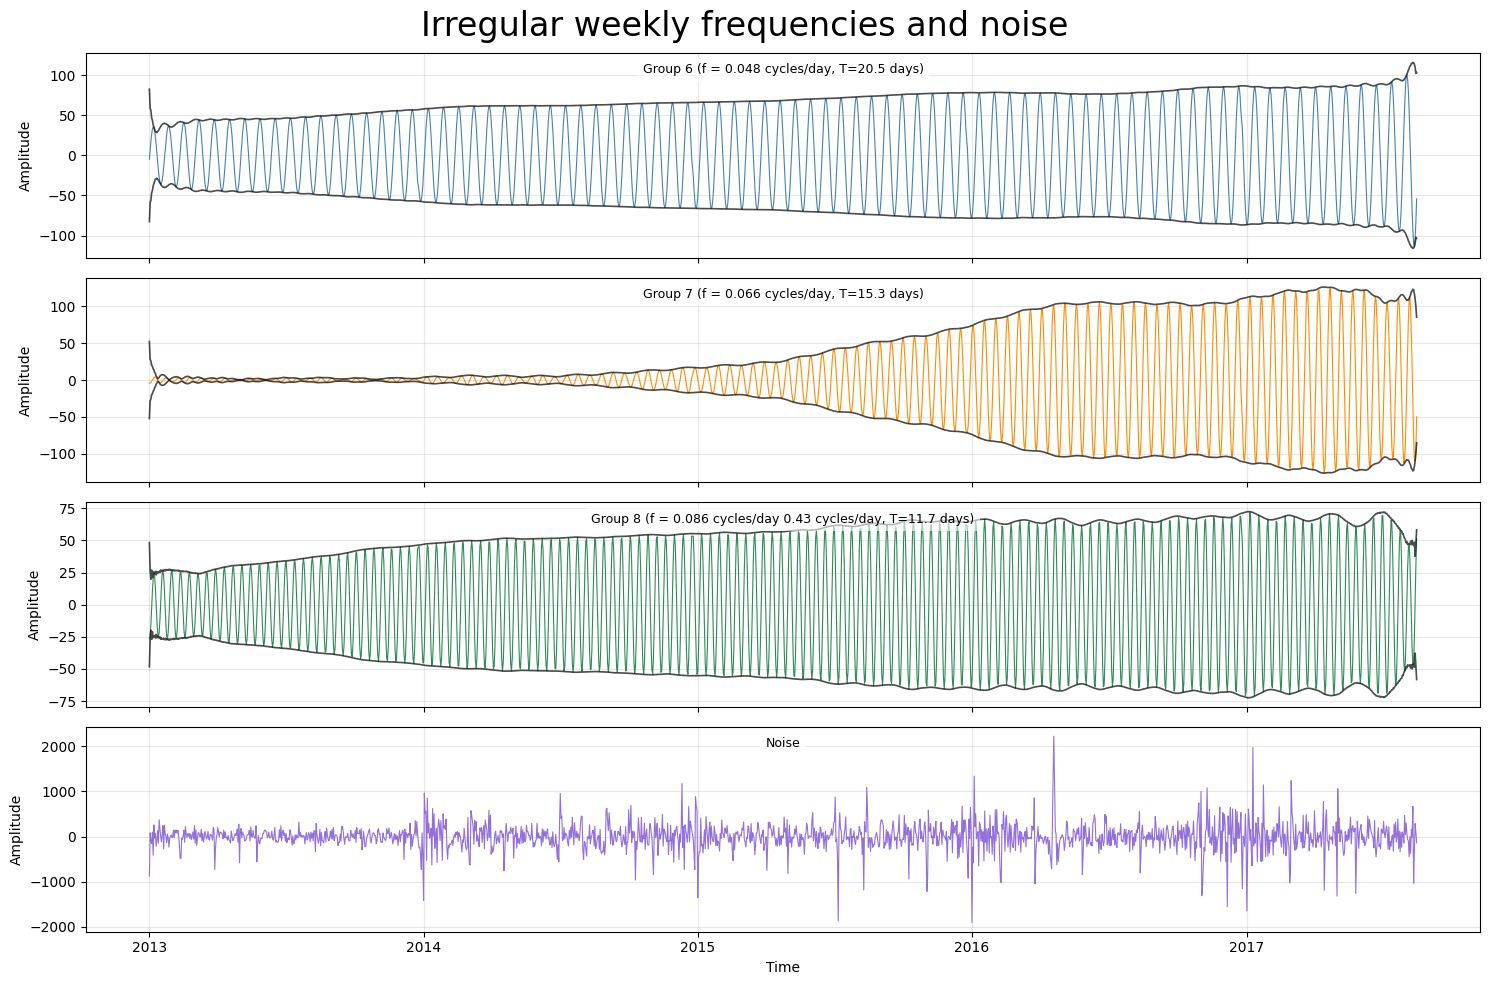

In [62]:
plt.close('all')

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)


# Plots each group
modes2 = {
    "Group 6 (f = 0.048 cycles/day, T=20.5 days)": rec_groups["group6"],
    "Group 7 (f = 0.066 cycles/day, T=15.3 days)": rec_groups["group7"],
    "Group 8 (f = 0.086 cycles/day 0.43 cycles/day, T=11.7 days)": rec_groups["group8"],
    "Noise": rec_groups["noise"]
}

colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

x = sales_ts.index
for ax, (title, signal), color in zip(axes, modes2.items(), colors):
    sig_np = signal.cpu().numpy()
    
    ax.plot(x, sig_np, color=color, lw=0.8)
    
    #  # Envelope for oscillations
    if title != "Noise":
        env = np.abs(hilbert(sig_np))
        ax.plot(x, env,  color='black', lw=1.2, alpha=0.7)
        ax.plot(x, -env, color='black', lw=1.2, alpha=0.7)
    
    ax.text(0.5, 0.95, title,
            transform=ax.transAxes,
            ha='center', va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')

plt.suptitle("Irregular weekly frequencies and noise", fontsize = 24 )
plt.tight_layout()
plt.show()
plt.close(fig)

Max error: 6.366463e-12
RMSE:      7.230781e-13


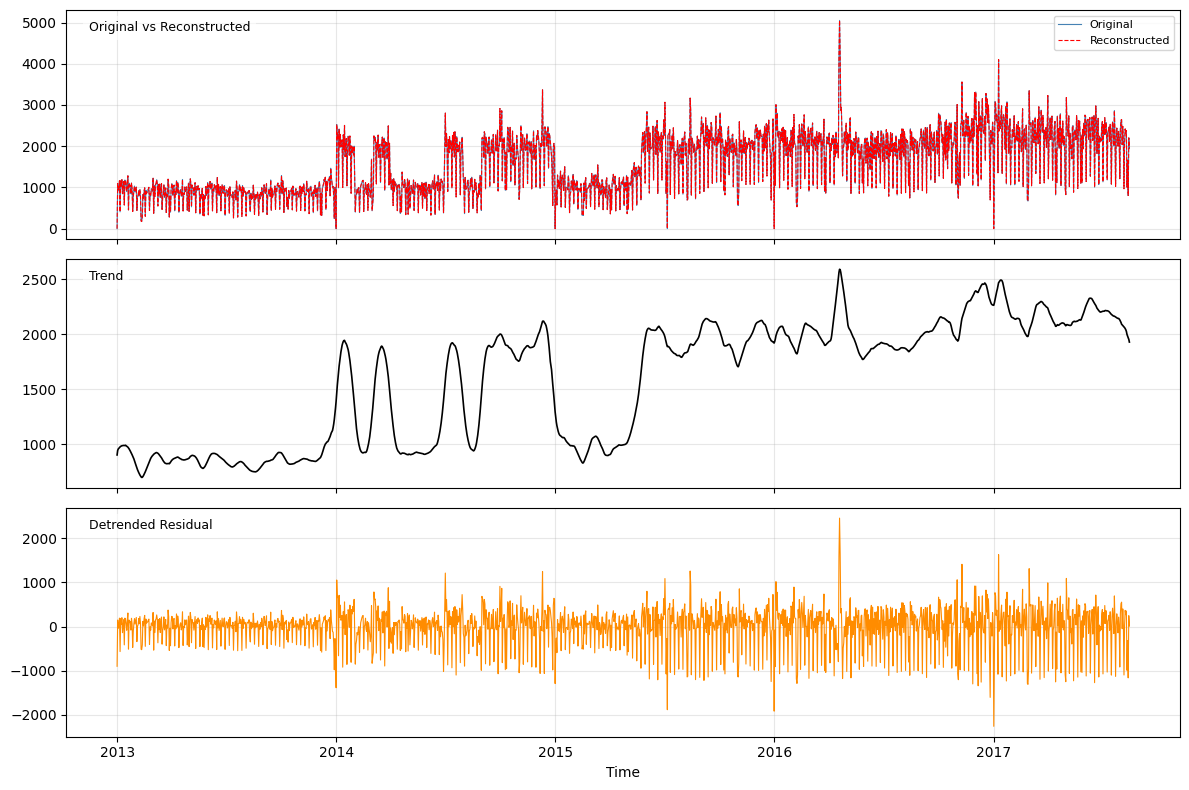

In [63]:
# Reconstruction of the total series
group1    = rec_groups["group1"].cpu().numpy()
group2    = rec_groups["group2"].cpu().numpy()
group3    = rec_groups["group3"].cpu().numpy()
group4    = rec_groups["group4"].cpu().numpy()
group5    = rec_groups["group5"].cpu().numpy()
group6    = rec_groups["group6"].cpu().numpy()
group7    = rec_groups["group7"].cpu().numpy()
group8    = rec_groups["group8"].cpu().numpy()
noise     = rec_groups["noise"].cpu().numpy()


reconstructed = trend_np + group1 + group2 + group3 + group4  + group5  + group6 + group7 + group8 + noise

# Comparing series
residual = sales_np - reconstructed
print(f"Max error: {np.max(np.abs(residual)):.6e}")
print(f"RMSE:      {np.sqrt(np.mean(residual**2)):.6e}")


# Plotting the series

plt.close('all')

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

x=sales_ts.index
axes[0].plot(x, sales_ts, color='steelblue', lw=0.8, label='Original')
axes[0].plot(x, reconstructed, color='red', lw=0.8, linestyle='--', label='Reconstructed')
axes[0].legend(fontsize=8)
axes[0].text(0.02, 0.95, 'Original vs Reconstructed',
             transform=axes[0].transAxes, va='top', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, trend, color='black', lw=1.2)
axes[1].text(0.02, 0.95, 'Trend',
             transform=axes[1].transAxes, va='top', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, reconstructed - trend_np, color='darkorange', lw=0.8)
axes[2].text(0.02, 0.95, 'Detrended Residual',
             transform=axes[2].transAxes, va='top', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
axes[2].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()
plt.close(fig)

In [64]:
# Variance
variance_original = np.var(sales_ts)
variance_error    = np.var(sales_ts - reconstructed)

r2 = (1 - variance_error / variance_original) * 100
print(f"Explained Variance: {r2:.2f}%")

Explained Variance: 100.00%


The trend, the reconstructed oscillatory groups, and the residual component reproduce the original sales series with 100% explained variance, confirming the accuracy of the sequential SSA decomposition and reconstruction

# Conclusions:

* A first SSA with a small window length was applied to extract the trend. The increasing trend suggests a sustained growth in beverage sales throughout the study period, although the growth is not uniform and is accompanied by short-term fluctuations that are analyzed separately through the oscillatory components.

* After extracting the trend, a second SSA with a large window length was applied to the residual to extract the periodicities. Weekly and subweekly modes were found. The weekly seasonal component accounts for approximately 14.3% of the residual SSA energy. Although it is not the largest oscillatory contribution, its 7-day period is naturally associated with the weekly sales cycle. Interestingly, the 3.5-day oscillatory components contribute slightly more (14.9%), suggesting that sub-weekly variations play an important role in the residual dynamics.

* Oscillatory components with approximate periods of 21, 15, and 12 days were also identified. These longer-period oscillations may reflect additional processes affecting sales, such as promotional or operational activities, although their origin cannot be determined from SSA alone.

*  The residual noise accounts for approximately 44.4% of the residual SSA energy. This indicates that, although the principal oscillatory patterns were successfully identified, a substantial fraction of the residual variability is distributed among lower-energy components that were not assigned to the reconstructed oscillatory groups.





